# NB03 - Métricas, calibración y bondad de ajuste

**Objetivos de aprendizaje**

- Evaluar un clasificador logístico más allá del accuracy.
- Interpretar matriz de confusión, ROC-AUC y curvas precisión-recall.
- Revisar calibración probabilística.
- Implementar desde cero el test de Hosmer-Lemeshow.
- Ver cómo el umbral de decisión cambia precisión y recall.

**Referencias de este notebook**

- Hosmer & Lemeshow (1980): proponen el test de bondad de ajuste implementado aquí.
- Hosmer, Lemeshow & Sturdivant (2013): sistematizan diagnóstico y evaluación de modelos logísticos.
- He & Garcia (2009): explican por qué ROC y precisión-recall son importantes, especialmente con desbalance.


In [1]:
%matplotlib inline
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('png')
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

# Los notebooks pueden ejecutarse desde la raiz del repo o desde notebooks/.
# Este bloque localiza la raiz y agrega src/ al path de importacion.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from utils import (
    COLOR_PALETTE,
    RANDOM_STATE,
    get_train_test_split,
    load_binary_iris,
    load_processed_splits,
    plot_coefficients,
    plot_decision_boundary,
    plot_regularization_path,
    plot_sigmoid,
    save_processed_splits,
    set_plot_style,
)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
set_plot_style()
np.random.seed(RANDOM_STATE)

DATA_DIR = PROJECT_ROOT / "data" / "processed"

from scipy.stats import chi2
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    auc,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)


## 1. Modelo base y matriz de confusión

Ajustamos una regresión logística L2 moderada sobre los splits compartidos. La matriz de confusión separa aciertos y errores por clase, lo que permite derivar métricas como precisión, recall, F1 y especificidad.

**Hiperparámetros del modelo base.** `C=1.0` es el valor por defecto de scikit-learn y representa regularización L2 moderada; aquí funciona como punto de referencia, no como resultado de tuning. `solver='lbfgs'` es apropiado para L2 con pocos predictores, `max_iter=5000` evita paradas prematuras y el umbral inicial `0.5` es la convención antes de estudiar otros puntos operativos.


,metrica,valor
0,accuracy,0.9000
1,precision,0.9286
2,recall/sensibilidad,0.8667
3,F1,0.8966
4,especificidad,0.9333


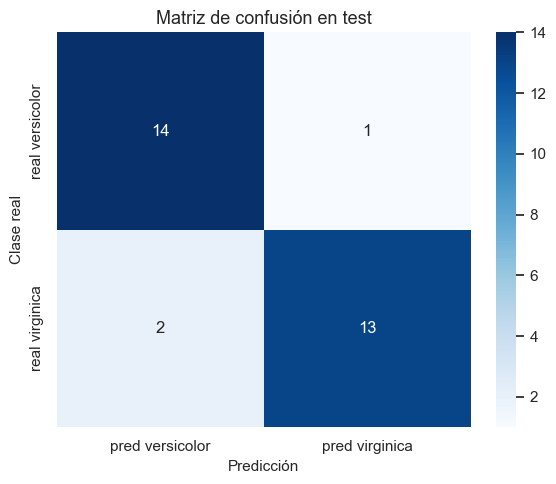

In [2]:
data = load_processed_splits(DATA_DIR)
X_train_scaled = data["X_train_scaled"]
X_test_scaled = data["X_test_scaled"]
y_train = data["y_train"]
y_test = data["y_test"]

# C=1.0 deja regularización L2 moderada y sirve como baseline reproducible.
# lbfgs es estable para L2; max_iter=5000 asegura convergencia sin alterar el objetivo estadístico.
model = LogisticRegression(C=1.0, penalty="l2", solver="lbfgs", max_iter=5000, random_state=RANDOM_STATE)
model.fit(X_train_scaled, y_train)

y_prob = model.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
metrics_table = pd.DataFrame(
    {
        "metrica": ["accuracy", "precision", "recall/sensibilidad", "F1", "especificidad"],
        "valor": [
            accuracy_score(y_test, y_pred),
            precision_score(y_test, y_pred),
            recall_score(y_test, y_pred),
            f1_score(y_test, y_pred),
            tn / (tn + fp),
        ],
    }
)
display(metrics_table.round(4))

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["pred versicolor", "pred virginica"],
    yticklabels=["real versicolor", "real virginica"],
    ax=ax,
)
ax.set_title("Matriz de confusión en test")
ax.set_xlabel("Predicción")
ax.set_ylabel("Clase real")
fig.tight_layout()
plt.show()


**Interpretación.** El accuracy resume todos los aciertos, pero precisión y recall distinguen tipos de error. En problemas reales, confundir una clase puede ser mucho más costoso que confundir la otra.


## 2. Curva ROC y AUC

La curva ROC evalúa todos los umbrales posibles comparando tasa de verdaderos positivos contra tasa de falsos positivos.


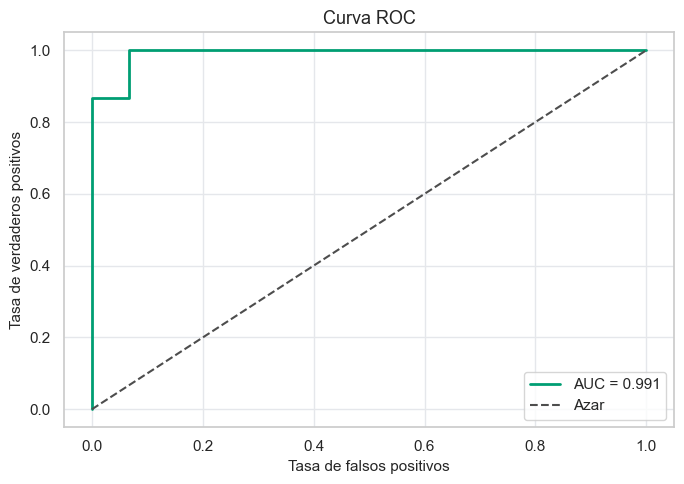

In [3]:
# La curva ROC evalúa la separación del ranking de probabilidades para todos los umbrales.
fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color=COLOR_PALETTE["decision"], linewidth=2, label=f"AUC = {roc_auc:.3f}")
ax.plot([0, 1], [0, 1], color=COLOR_PALETTE["neutral"], linestyle="--", label="Azar")
ax.set_title("Curva ROC")
ax.set_xlabel("Tasa de falsos positivos")
ax.set_ylabel("Tasa de verdaderos positivos")
ax.legend()
fig.tight_layout()
plt.show()


**Interpretación.** Un AUC cercano a 1 indica buen ordenamiento probabilístico: las `virginica` tienden a recibir probabilidades mayores que las `versicolor`. He & Garcia (2009) recomiendan mirar este tipo de métricas cuando la distribución de clases importa.


## 3. Curva precisión-recall

La curva PR se concentra en la calidad de las predicciones positivas. Suele ser más informativa que ROC cuando una clase es rara, tema que retomaremos en NB08.


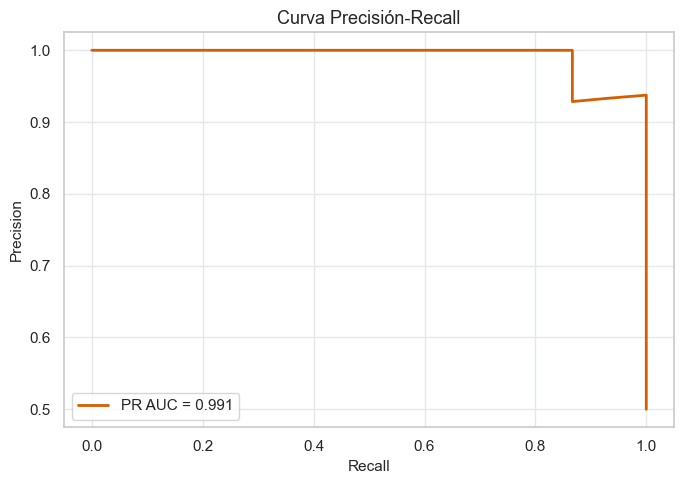

In [4]:
# La curva precisión-recall enfatiza el rendimiento sobre la clase positiva, especialmente útil con desbalance.
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall, precision, color=COLOR_PALETTE["virginica"], linewidth=2, label=f"PR AUC = {pr_auc:.3f}")
ax.set_title("Curva Precisión-Recall")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend()
fig.tight_layout()
plt.show()


**Interpretación.** Precisión y recall se mueven en tensión: al exigir menos evidencia para predecir `virginica`, sube el recall pero puede caer la precisión. Esta tensión es central en decisiones con costo.


## 4. Calibración

Un modelo calibrado no solo ordena bien, también asigna probabilidades realistas. Si predice 0.8 para un grupo de observaciones, esperamos que cerca del 80% sean positivas.

**Parámetro de calibración.** `n_bins=5` divide las 30 observaciones de test en pocos grupos para que cada punto del reliability diagram tenga suficientes casos. Con más bins la gráfica sería más granular, pero también más ruidosa en este dataset pequeño.


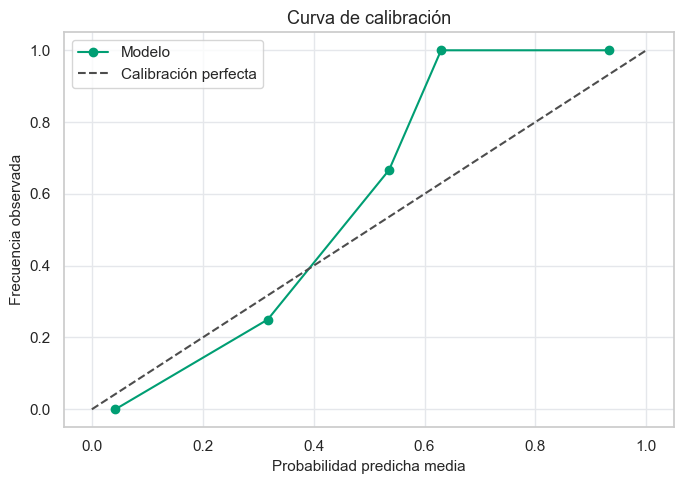

In [5]:
# n_bins=5 evita deciles demasiado pequeños: con 30 casos de test, cada bin conserva señal interpretable.
# strategy="uniform" reparte el eje de probabilidad en intervalos iguales.
prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=5, strategy="uniform")

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(prob_pred, prob_true, marker="o", color=COLOR_PALETTE["decision"], label="Modelo")
ax.plot([0, 1], [0, 1], color=COLOR_PALETTE["neutral"], linestyle="--", label="Calibración perfecta")
ax.set_title("Curva de calibración")
ax.set_xlabel("Probabilidad predicha media")
ax.set_ylabel("Frecuencia observada")
ax.legend()
fig.tight_layout()
plt.show()


**Interpretación.** La muestra de test es pequeña, así que la curva puede verse escalonada. Aun así, el gráfico ilustra la pregunta de calibración: si las probabilidades estimadas coinciden con frecuencias observadas.


## 5. Test de Hosmer-Lemeshow desde cero

Hosmer & Lemeshow (1980) agrupan observaciones por riesgo predicho y comparan eventos observados contra esperados. Un p-valor pequeño sugiere falta de ajuste; un p-valor grande no prueba que el modelo sea perfecto, solo que el test no detecta discrepancias fuertes.


In [6]:
def hosmer_lemeshow_test(y_true, y_probability, groups=10):
    # Ordenamos por riesgo predicho y formamos grupos con tamaños
    # similares. qcut puede fusionar grupos si hay probabilidades repetidas.
    df = pd.DataFrame({"y": y_true, "p": y_probability}).sort_values("p")
    df["group"] = pd.qcut(df["p"], q=groups, duplicates="drop")

    grouped = df.groupby("group", observed=True)
    observed_events = grouped["y"].sum()
    expected_events = grouped["p"].sum()
    n_group = grouped.size()
    observed_nonevents = n_group - observed_events
    expected_nonevents = n_group - expected_events

    # Estadistico chi-cuadrado con proteccion numérica para grupos pequeños.
    eps = 1e-12
    statistic = (
        ((observed_events - expected_events) ** 2 / np.maximum(expected_events, eps))
        + ((observed_nonevents - expected_nonevents) ** 2 / np.maximum(expected_nonevents, eps))
    ).sum()
    dof = max(len(observed_events) - 2, 1)
    p_value = 1 - chi2.cdf(statistic, dof)

    table = pd.DataFrame(
        {
            "n": n_group,
            "observados_evento": observed_events,
            "esperados_evento": expected_events,
            "observados_no_evento": observed_nonevents,
            "esperados_no_evento": expected_nonevents,
        }
    )
    return statistic, dof, p_value, table


hl_stat, hl_dof, hl_p, hl_table = hosmer_lemeshow_test(y_test, y_prob, groups=10)
print(f"HL chi2 = {hl_stat:.3f}, gl = {hl_dof}, p-valor = {hl_p:.3f}")
display(hl_table.round(3))


HL chi2 = 2.366, gl = 8, p-valor = 0.968


,n,observados_evento,esperados_evento,observados_no_evento,esperados_no_evento
group,,,,,
"(0.00049, 0.00792]",3,0,0.006,3,2.994
"(0.00792, 0.0259]",3,0,0.046,3,2.954
"(0.0259, 0.118]",3,0,0.120,3,2.880
"(0.118, 0.25]",3,0,0.540,3,2.460
"(0.25, 0.445]",3,1,1.022,2,1.978
"(0.445, 0.605]",3,2,1.608,1,1.392
"(0.605, 0.872]",3,3,2.345,0,0.655
"(0.872, 0.911]",3,3,2.701,0,0.299
"(0.911, 0.977]",3,3,2.866,0,0.134


**Interpretación.** El test compara riesgos predichos con eventos observados por deciles. En muestras pequeñas debe leerse con cautela, pero es una herramienta clásica de diagnóstico en la tradicion de Hosmer, Lemeshow & Sturdivant (2013).


## 6. El umbral de decisión

La probabilidad es continua; la clase final depende de un umbral. Cambiarlo altera el balance entre precisión y recall.

**Rango de umbrales.** `np.linspace(0.1, 0.9, 17)` evalúa puntos cada 0.05: suficiente resolución para ver el intercambio precisión-recall sin convertir la tabla en ruido. No incluimos 0 ni 1 porque producirían decisiones degeneradas.


,threshold,precision,recall,f1
0,0.10,0.714,1.000,0.833
1,0.15,0.789,1.000,0.882
2,0.20,0.789,1.000,0.882
3,0.25,0.833,1.000,0.909
4,0.30,0.882,1.000,0.938
5,0.35,0.882,1.000,0.938
6,0.40,0.933,0.933,0.933
7,0.45,0.933,0.933,0.933
8,0.50,0.929,0.867,0.897
9,0.55,1.000,0.867,0.929


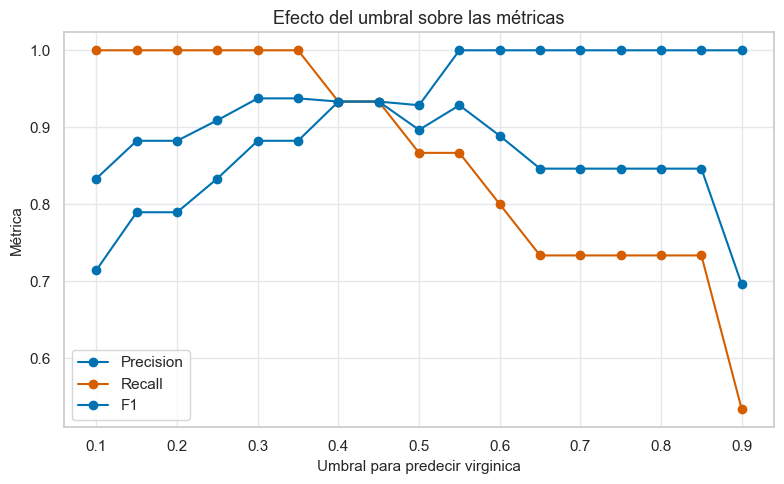

In [7]:
# Evaluamos umbrales de 0.10 a 0.90 en pasos de 0.05; evitamos 0 y 1 por ser reglas degeneradas.
threshold_rows = []
for threshold in np.linspace(0.1, 0.9, 17):
    pred_threshold = (y_prob >= threshold).astype(int)
    threshold_rows.append(
        {
            "threshold": threshold,
            "precision": precision_score(y_test, pred_threshold, zero_division=0),
            "recall": recall_score(y_test, pred_threshold, zero_division=0),
            "f1": f1_score(y_test, pred_threshold, zero_division=0),
        }
    )

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df.round(3))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="Precision")
ax.plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="Recall")
ax.plot(threshold_df["threshold"], threshold_df["f1"], marker="o", label="F1")
ax.set_title("Efecto del umbral sobre las métricas")
ax.set_xlabel("Umbral para predecir virginica")
ax.set_ylabel("Métrica")
ax.legend()
fig.tight_layout()
plt.show()


**Interpretación.** Un umbral bajo predice más positivos y suele elevar recall; un umbral alto exige más evidencia y puede elevar precisión. La decisión óptima depende del costo relativo de cada error.


## Resumen y conexion con la literatura

Hosmer & Lemeshow (1980) aportan el test de bondad de ajuste implementado aquí mediante grupos de riesgo. Hosmer, Lemeshow & Sturdivant (2013) dan el marco aplicado para diagnosticar modelos logísticos con confusión, calibración y ajustes de umbral. He & Garcia (2009) conectan ROC y precisión-recall con el problema de clases desbalanceadas que abordaremos en NB08.
